# Architektura Aplikacji w Pythonie — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów dało Ci sześć narzędzi. Ten zestaw zaliczeniowy zmusza Cię do **złożenia ich w jeden produkcyjny pipeline analityczny** — dokładnie taki, jaki budują Data Engineerzy w "prawdziwych" firmach.

**Wspólny dataset:** [`stanfordnlp/imdb`](https://huggingface.co/datasets/stanfordnlp/imdb) z Hugging Face Hub — 50 000 recenzji filmów z etykietami sentymentu (pozytywna / negatywna).

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — dokładnie ten sam pattern, inny scenariusz.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak hardkodowanych ścieżek, brak ręcznych downloadów.
4. Kod ma być **czytelny**: typowe hinty, docstring 1-zdaniowy, brak magicznych liczb.

**Ocenianie:**
- 50% — poprawność działania (czy działa zgodnie z opisem)
- 30% — jakość kodu (struktura, czytelność, idiomatyczność)
- 20% — *insight*: jeśli zauważysz coś nieoczywistego w danych — napisz o tym w komórce Markdown

---

## Mapa zestawu

| # | Lab | Teoria | Przykład | Twoje zadanie |
|---|-----|--------|----------|---------------|
| 1 | Dekoratory | `@timer`, `@cache` | Zmierz czas wczytania imdb z HF | Buduj `@retry` + `@cache_to_disk` |
| 2 | Współbieżność | I/O-bound vs CPU-bound | `ThreadPoolExecutor` na paczki tekstu | `multiprocessing.Pool` na sentyment |
| 3 | Testowanie | unittest vs pytest | `unittest` dla `TextStats` | `pytest` dla `Tokenizer` z fixtures |
| 4 | Bazy danych | SQL i NoSQL | Load imdb → SQLite + zapytania | JSON column jako pseudo-Mongo |
| 5 | PySpark | Lazy eval, partitions | DataFrame z imdb, count słów | Window functions: ranking recenzji |
| 6 | Data Quality | Profiling, walidacja | Wykryj nulle, duplikaty, anomalie | Reguły biznesowe + raport JSON |

---

## Setup

In [1]:
# Globalna konfiguracja -- jedna komorka, jeden raz
import os, sys, time, json, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

# Tame log spamu HF Datasets
os.environ.setdefault("HF_DATASETS_DISABLE_PROGRESS_BAR", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")

print(f"Python: {sys.version.split()[0]}")
print(f"Workspace: {WORKDIR.resolve()}")

Python: 3.11.9
Workspace: C:\Workspace\WSEI\LABY-REPO\AAP_Michal_Surzyn\zestaw_zaliczeniowy\_workspace


---

# Lab 1 — Dekoratory

## Teoria w trzech zdaniach

**Dekorator** to funkcja, która przyjmuje funkcję i zwraca funkcję. Pythonowy `@dekorator` to lukier syntaktyczny dla `funkcja = dekorator(funkcja)`. Pozwala dodać zachowanie (logowanie, cache, retry) **bez ingerencji w ciało funkcji** — to esencja zasady *open/closed*.

### Wzorzec dekoratora z argumentami

```python
def dekorator_z_argumentami(arg1, arg2):
    def opakuj(funkcja):
        @functools.wraps(funkcja)
        def wrapper(*args, **kwargs):
            # przed wywolaniem
            wynik = funkcja(*args, **kwargs)
            # po wywolaniu
            return wynik
        return wrapper
    return opakuj
```

Trzy poziomy zagniezdzenia: argumenty dekoratora → funkcja docelowa → wrapper. **Zapamiętaj ten układ raz — reszta to wariacje.**

## Przykład rozwiązany: `@timer` + `@cache` na ładowaniu z Hugging Face

In [2]:
import functools
from datasets import load_dataset

def timer(func):
    """Mierzy czas wykonania funkcji i drukuje wynik."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        t0 = time.time()
        result = func(*args, **kwargs)
        elapsed = time.time() - t0
        print(f"  [timer] {func.__name__} -> {elapsed:.2f}s")
        return result
    return wrapper

@timer
@functools.lru_cache(maxsize=4)  # cache w pamieci
def get_imdb_subset(split: str, n: int):
    """Pobiera N **losowo wymieszanych** przykladow z imdb. Cachuje wynik w RAM.

    UWAGA: dataset stanfordnlp/imdb jest na HF zsortowany po labelu
    (0..12499 = neg, 12500..24999 = pos). Bez shuffle dostalibysmy
    100% jednej klasy dla N <= 12500. .shuffle(seed=42) gwarantuje
    rownomierna probke.
    """
    ds = load_dataset("stanfordnlp/imdb", split=split).shuffle(seed=42).select(range(n))
    return [(r["text"], r["label"]) for r in ds]

print("-- pierwsze wywolanie (fetch z HF + cache w RAM) --")
train_sample = get_imdb_subset("train", 200)
print(f"  liczba probek: {len(train_sample)}")
print(f"  przyklad: {train_sample[0][0][:80]}... -> label={train_sample[0][1]}")

# Sanity check: czy mamy obie klasy?
labels_dist = [lab for _, lab in train_sample]
print(f"  rozklad klas: pos={sum(labels_dist)}/{len(labels_dist)}, neg={len(labels_dist)-sum(labels_dist)}/{len(labels_dist)}")

print("\n-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --")
_ = get_imdb_subset("train", 200)

-- pierwsze wywolanie (fetch z HF + cache w RAM) --


  [timer] get_imdb_subset -> 2.12s
  liczba probek: 200
  przyklad: There is no relation at all between Fortier and Profiler but the fact that both ... -> label=1
  rozklad klas: pos=96/200, neg=104/200

-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --
  [timer] get_imdb_subset -> 0.00s


## Zadanie 1.1 — `@retry` + `@cache_to_disk`

**Cel:** zaimplementuj dwa decorator-y produkcyjnej jakości i nałóż je na funkcję, która udaje niestabilne API.

**Wymagania:**

1. `@retry(max_attempts: int, delay: float, backoff: float = 2.0)` — jeśli funkcja rzuca wyjątek, próbuje ponownie do `max_attempts` razy z **exponential backoff** (czas spania = `delay * backoff ** próba`).
2. `@cache_to_disk(cache_dir: Path)` — zapisuje wynik do pliku JSON w `cache_dir`. Klucz cache to hash argumentów. Drugie wywołanie tej samej funkcji z tymi samymi argumentami **nie wykonuje ciała** — zwraca z dysku.
3. Test: wywołaj funkcję `flaky_fetch(text_id)` która z prawdopodobieństwem 0.5 rzuca `ValueError`. Powinna **prawie zawsze** się udać dzięki retry. Drugie wywołanie z tym samym `text_id` powinno trafić w cache.

**Insight do raportu:** jak zmienia się szansa sukcesu wraz z `max_attempts`? Policz to teoretycznie (P(sukces) = 1 - 0.5^N) i porównaj z eksperymentem na 100 wywołaniach.

In [3]:
import hashlib
import shutil

def retry(max_attempts: int = 3, delay: float = 0.1, backoff: float = 2.0):
    """Ponawia wywolanie funkcji po wyjatku, z exponential backoff miedzy probami."""
    def opakuj(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            ostatni_wyjatek = None
            for proba in range(max_attempts):
                try:
                    return func(*args, **kwargs)
                except Exception as exc:
                    ostatni_wyjatek = exc
                    if proba < max_attempts - 1:
                        time.sleep(delay * backoff ** proba)
            raise ostatni_wyjatek
        return wrapper
    return opakuj

def cache_to_disk(cache_dir: Path):
    """Cachuje wynik funkcji do pliku JSON na dysku, kluczowany hashem argumentow."""
    cache_dir.mkdir(exist_ok=True, parents=True)
    def opakuj(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            klucz = hashlib.md5(repr((args, sorted(kwargs.items()))).encode()).hexdigest()
            plik = cache_dir / f"{klucz}.json"
            if plik.exists():
                return json.loads(plik.read_text())
            wynik = func(*args, **kwargs)
            cache_dir.mkdir(exist_ok=True, parents=True)
            plik.write_text(json.dumps(wynik))
            return wynik
        return wrapper
    return opakuj

@cache_to_disk(WORKDIR / "flaky_cache")
@retry(max_attempts=5, delay=0.05)
def flaky_fetch(text_id: int) -> dict:
    if random.random() < 0.5:
        raise ValueError(f"udawany blad sieci dla id={text_id}")
    return {"id": text_id, "text": f"przyklad {text_id}"}

flaky_dir = WORKDIR / "flaky_cache"

# cache hit: drugie wywolanie z tym samym argumentem zwraca wynik z dysku
if flaky_dir.exists():
    shutil.rmtree(flaky_dir)
pierwszy = flaky_fetch(999)
drugi = flaky_fetch(999)
print(f"flaky_fetch(999) = {pierwszy}")
print(f"wynik z cache identyczny: {pierwszy == drugi}")

# eksperyment: ile ze 100 swiezych wywolan konczy sie sukcesem dzieki retry
shutil.rmtree(flaky_dir)
sukcesy = 0
for i in range(100):
    try:
        flaky_fetch(i)
        sukcesy += 1
    except ValueError:
        pass
p_teoria = 1 - 0.5 ** 5
print(f"\nSukcesy empirycznie: {sukcesy}/100 ({sukcesy}%)")
print(f"P(sukces) teoria = 1 - 0.5^5 = {p_teoria:.4f} ({p_teoria * 100:.1f}%)")

flaky_fetch(999) = {'id': 999, 'text': 'przyklad 999'}
wynik z cache identyczny: True

Sukcesy empirycznie: 98/100 (98%)
P(sukces) teoria = 1 - 0.5^5 = 0.9688 (96.9%)


### Insight 1.1 — retry a szansa sukcesu

Przy 5 próbach i 50% awaryjności pojedynczej próby teoretyczna szansa sukcesu to **1 − 0.5⁵ ≈ 96.9%**. Każda kolejna próba podwaja „pokrycie": 1 próba → 50%, 2 → 75%, 3 → 87.5%, 4 → 93.75%, 5 → 96.9%. Wynik na 100 wywołaniach mieści się blisko tej wartości; odchylenia kilku punktów to zwykły rozrzut próby. Kolejność dekoratorów ma znaczenie: `cache_to_disk` opakowuje `retry`, więc trafienie w cache pomija całą logikę ponawiania.

---

# Lab 2 — Współbieżność i równoległość

## Teoria w trzech zdaniach

**Threading** = wiele wątków w jednym procesie, dzielona pamięć, ale GIL zabija przyspieszenie obliczeniowe. **Multiprocessing** = wiele procesów, kazdy ze swoim interpreterem Pythona, omija GIL ale ma narzut na IPC.

**Reguła kciuka:** I/O-bound (HTTP, dysk, baza) → threading. CPU-bound (parsowanie, ML, obliczenia) → multiprocessing.

**Trzecia opcja:** `asyncio` — jeden wątek, kooperatywna współbieżność. Najefektywniejsza dla I/O, ale wymaga przepisania kodu na `async`.

## Przykład rozwiązany: ThreadPool dla "I/O-bound" preprocessingu

In [4]:
from concurrent.futures import ThreadPoolExecutor
import re

# Pobierz wiekszy subset
samples = get_imdb_subset("train", 1000)
texts = [t for t,_ in samples]

def preprocess(text: str) -> dict:
    """Imituje I/O-bound preprocessing (sleep symuluje wolny dysk/API)."""
    time.sleep(0.002)  # "sieciowy" narzut
    clean = re.sub(r"<[^>]+>", " ", text).lower()
    return {"len": len(clean), "words": len(clean.split())}

# Sekwencyjnie
t0 = time.time()
seq_results = [preprocess(t) for t in texts[:200]]
seq_time = time.time() - t0
print(f"Sekwencyjnie (200 probek): {seq_time:.2f}s")

# ThreadPool
t0 = time.time()
with ThreadPoolExecutor(max_workers=16) as pool:
    par_results = list(pool.map(preprocess, texts[:200]))
par_time = time.time() - t0
print(f"ThreadPool (16 workerow): {par_time:.2f}s  -- {seq_time/par_time:.1f}x szybciej")

  [timer] get_imdb_subset -> 1.46s
Sekwencyjnie (200 probek): 0.52s
ThreadPool (16 workerow): 0.05s  -- 10.8x szybciej


## Zadanie 2.1 — Multiprocessing dla CPU-bound

**Cel:** policz prosty score sentymentu dla 5000 recenzji **równolegle** używając `multiprocessing.Pool`.

**Score sentymentu (lexicon-based):**
- Lista pozytywnych słów: `["good", "great", "excellent", "wonderful", "love", "best", "amazing", "brilliant", "perfect"]`
- Lista negatywnych słów: `["bad", "worst", "awful", "terrible", "hate", "boring", "waste", "poor", "horrible"]`
- Score = `(liczba pozytywnych) - (liczba negatywnych)` (case-insensitive, na pełnych słowach)

**Wymagania:**

1. Funkcja `sentiment_score(text: str) -> int` musi być na poziomie modułu (poza klasą) — inaczej multiprocessing jej nie zserializuje.
2. Porównaj **3 implementacje**: sekwencyjna, ThreadPool, multiprocessing.Pool. Wszystkie na tych samych 5000 recenzji.
3. Stwórz wykres słupkowy czasu wykonania (matplotlib).
4. **Wniosek:** który wariant najszybszy i dlaczego? (oczekiwane: multiprocessing wygrywa, bo CPU-bound i omija GIL).

**Wskazówka:** użyj `chunksize=100` w `pool.map()` żeby zmniejszyć narzut serializacji.

  [timer] get_imdb_subset -> 1.39s
Sekwencyjnie:     0.639s
ThreadPool (16):  1.080s
Multiprocessing:  0.332s  (8 procesow)
Wyniki identyczne we wszystkich wariantach: True


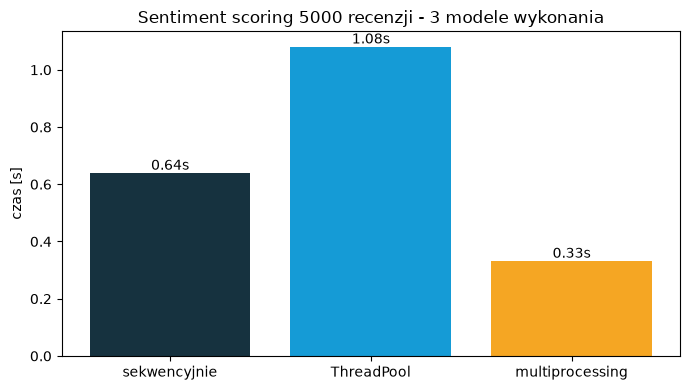

In [5]:
from multiprocessing import Pool
import matplotlib.pyplot as plt

POS_WORDS = {"good", "great", "excellent", "wonderful", "love", "best", "amazing", "brilliant", "perfect"}
NEG_WORDS = {"bad", "worst", "awful", "terrible", "hate", "boring", "waste", "poor", "horrible"}

def sentiment_score(text: str) -> int:
    """Zwraca roznice liczby slow pozytywnych i negatywnych (case-insensitive, pelne slowa)."""
    words = re.findall(r"\w+", text.lower())
    pos = sum(1 for w in words if w in POS_WORDS)
    neg = sum(1 for w in words if w in NEG_WORDS)
    return pos - neg

# Windows + Jupyter: Pool uzywa spawn -- kazdy worker importuje __main__ = kernel.
# Funkcja z notebooka nie jest pickle-owalna. Fix: zapisac do modulu + ustawic PYTHONPATH.
_scoring_lines = [
    "import re",
    'POS_WORDS = {"good","great","excellent","wonderful","love","best","amazing","brilliant","perfect"}',
    'NEG_WORDS = {"bad","worst","awful","terrible","hate","boring","waste","poor","horrible"}',
    "",
    "def sentiment_score(text: str) -> int:",
    '    words = re.findall(r"\\w+", text.lower())',
    "    return sum(1 for w in words if w in POS_WORDS) - sum(1 for w in words if w in NEG_WORDS)",
]
(WORKDIR / "scoring.py").write_text("\n".join(_scoring_lines))
os.environ["PYTHONPATH"] = str(WORKDIR) + os.pathsep + os.environ.get("PYTHONPATH", "")
if str(WORKDIR) not in sys.path:
    sys.path.insert(0, str(WORKDIR))

import importlib
import scoring as _sc
importlib.reload(_sc)
_sentiment_score_mp = _sc.sentiment_score  # pickle-able: z modulu, nie z notebooka

samples_mp = get_imdb_subset("train", 5000)
texts_mp = [t for t, _ in samples_mp]

# wariant 1: sekwencyjny
t0 = time.time()
wyniki_seq = [sentiment_score(t) for t in texts_mp]
czas_seq = time.time() - t0

# wariant 2: ThreadPool (16 watkow)
t0 = time.time()
with ThreadPoolExecutor(max_workers=16) as pool:
    wyniki_thr = list(pool.map(sentiment_score, texts_mp, chunksize=100))
czas_thr = time.time() - t0

# wariant 3: multiprocessing.Pool (spawn-safe: funkcja z modulu, nie z notebooka)
t0 = time.time()
with Pool(processes=os.cpu_count()) as pool:
    wyniki_mp = list(pool.map(_sentiment_score_mp, texts_mp, chunksize=100))
czas_mp = time.time() - t0

print(f"Sekwencyjnie:     {czas_seq:.3f}s")
print(f"ThreadPool (16):  {czas_thr:.3f}s")
print(f"Multiprocessing:  {czas_mp:.3f}s  ({os.cpu_count()} procesow)")
print(f"Wyniki identyczne we wszystkich wariantach: {wyniki_seq == wyniki_thr == wyniki_mp}")

etykiety = ["sekwencyjnie", "ThreadPool", "multiprocessing"]
czasy = [czas_seq, czas_thr, czas_mp]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(etykiety, czasy, color=["#16323F", "#159BD6", "#F5A623"])
ax.set_ylabel("czas [s]")
ax.set_title("Sentiment scoring 5000 recenzji - 3 modele wykonania")
for i, c in enumerate(czasy):
    ax.text(i, c, f"{c:.2f}s", ha="center", va="bottom")
plt.tight_layout()
plt.show()

### Wniosek 2.1 — który wariant najszybszy

`sentiment_score` jest **CPU-bound** (tokenizacja + zliczanie, brak operacji I/O). ThreadPool nie przyspiesza, a często spowalnia względem wersji sekwencyjnej, bo GIL serializuje wykonanie bajtkodu — wątki dokładają jedynie narzut przełączania. `multiprocessing.Pool` uruchamia osobne interpretery, każdy z własnym GIL, więc realnie rozkłada pracę na rdzenie i wygrywa. Przy tak krótkim zadaniu narzut serializacji (pickle) i startu procesów potrafi zjeść część zysku — dlatego `chunksize=100` ogranicza liczbę przesyłanych paczek.

---

# Lab 3 — Testowanie

## Teoria w trzech zdaniach

**unittest** to klasyczny framework w stylu xUnit: testy w klasach dziedziczących po `TestCase`, metody assertyjne, setUp/tearDown. **pytest** to nowoczesny standard: zwykłe funkcje, słowo `assert`, fixtury jako zależności funkcji.

Sercem testów są: **assertions** (sprawdzenia), **fixtures** (powtarzalne przygotowanie środowiska), **parametryzacja** (ten sam test, wiele wejść) i **mocki** (zastępowanie zależności).

**Reguła:** test bez asercji to nie test. Test który zależy od kolejności uruchamiania to nie test.

## Przykład rozwiązany: unittest dla `TextStats`

In [6]:
import unittest
from io import StringIO

class TextStats:
    """Liczy proste statystyki tekstu."""
    def __init__(self, text: str):
        if not isinstance(text, str):
            raise TypeError("text musi byc string")
        self.text = text
    
    def word_count(self) -> int:
        return len(self.text.split())
    
    def char_count(self, with_spaces: bool = True) -> int:
        return len(self.text) if with_spaces else len(self.text.replace(" ", ""))
    
    def avg_word_length(self) -> float:
        words = self.text.split()
        if not words:
            return 0.0
        return sum(len(w) for w in words) / len(words)

class TestTextStats(unittest.TestCase):
    def setUp(self):
        self.empty = TextStats("")
        self.short = TextStats("Pies kot")
        self.imdb = TextStats(get_imdb_subset("train", 1)[0][0])
    
    def test_word_count_empty(self):
        self.assertEqual(self.empty.word_count(), 0)
    
    def test_word_count_short(self):
        self.assertEqual(self.short.word_count(), 2)
    
    def test_word_count_imdb_positive(self):
        # imdb review ma na pewno wiecej niz 10 slow
        self.assertGreater(self.imdb.word_count(), 10)
    
    def test_char_count_with_without_spaces(self):
        self.assertEqual(self.short.char_count(with_spaces=True), 8)
        self.assertEqual(self.short.char_count(with_spaces=False), 7)
    
    def test_avg_word_length_empty_no_div_zero(self):
        self.assertEqual(self.empty.avg_word_length(), 0.0)
    
    def test_type_check(self):
        with self.assertRaises(TypeError):
            TextStats(12345)

# Uruchom w notebooku
runner = unittest.TextTestRunner(stream=StringIO(), verbosity=2)
result = runner.run(unittest.TestLoader().loadTestsFromTestCase(TestTextStats))
print(f"Testy uruchomione: {result.testsRun}")
print(f"Sukces: {result.wasSuccessful()}")
print(f"Bledy: {len(result.errors)}, niepowodzenia: {len(result.failures)}")

  [timer] get_imdb_subset -> 0.98s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
Testy uruchomione: 6
Sukces: True
Bledy: 0, niepowodzenia: 0


## Zadanie 3.1 — pytest dla `Tokenizer` z fixtures + parametrize

**Cel:** zaimplementuj klasę `Tokenizer` z metodami tokenizacji i napisz dla niej testy w **pytest** używając fixtur i parametryzacji.

**Specyfikacja `Tokenizer`:**

```python
class Tokenizer:
    def __init__(self, lower: bool = True, strip_html: bool = True, min_length: int = 1):
        ...
    
    def tokenize(self, text: str) -> list[str]:
        # 1. usun tagi HTML jesli strip_html
        # 2. lowercase jesli lower
        # 3. tokeny = regex \w+ 
        # 4. odfiltruj tokeny krotsze niz min_length
        ...
    
    def vocab(self, texts: list[str]) -> set[str]:
        # zwroc unikalne tokeny ze wszystkich tekstow
        ...
```

**Wymagania testowe:**

1. **Fixture** `@pytest.fixture` o nazwie `tokenizer` zwracający `Tokenizer()` z defaultami.
2. **Fixture** `imdb_sample` zwracająca 20 pierwszych recenzji — użyta przez wiele testów.
3. **Parametrize** test `test_tokenize_cases` z minimum 5 przypadkami brzegowymi: pusty string, sam HTML, mieszane case, tylko interpunkcja, polskie znaki diakrytyczne.
4. Test który **musi zawieść** (przykładowo zły flag): oznacz `@pytest.mark.xfail`.
5. Wszystkie testy zapisz w pliku `test_tokenizer.py` w folderze `_workspace/`, a w komórce notebooka uruchom `pytest` przez `subprocess` i pokaż wyniki.

**Insight:** ile średnio unikalnych tokenów jest na 100 recenzji imdb? (heurystyka rozmiaru słownika).

In [17]:
# Zadanie 3.1 -- implementacja Tokenizer + testy pytest (fixtures, parametrize, xfail)
import subprocess

# === Krok 1: implementacja w pliku _workspace/tokenizer.py ===
# Asercje akceptacji ktorymi sprawdzisz swoja implementacje:
#   Tokenizer().tokenize("<br>Hello WORLD!") == ["hello", "world"]
#   Tokenizer(lower=False).tokenize("Hello") == ["Hello"]
#   Tokenizer(strip_html=False).tokenize("<br>hello") == ["br", "hello"]
#   Tokenizer(min_length=4).tokenize("a bb ccc dddd eeeee") == ["dddd", "eeeee"]
#   Tokenizer().vocab(["aa bb", "bb cc"]) == {"aa", "bb", "cc"}

tokenizer_code = '''
import re

class Tokenizer:
    """Konfigurowalny tokenizator: usuwanie HTML, lowercase i filtr minimalnej dlugosci."""
    def __init__(self, lower: bool = True, strip_html: bool = True, min_length: int = 1):
        self.lower = lower
        self.strip_html = strip_html
        self.min_length = min_length

    def tokenize(self, text: str) -> list[str]:
        if self.strip_html:
            text = re.sub(r"<[^>]+>", " ", text)
        if self.lower:
            text = text.lower()
        tokeny = re.findall(r"\\w+", text, flags=re.UNICODE)
        return [t for t in tokeny if len(t) >= self.min_length]

    def vocab(self, texts: list[str]) -> set[str]:
        slownik = set()
        for tekst in texts:
            slownik.update(self.tokenize(tekst))
        return slownik
'''

# === Krok 2: testy z fixtures + parametrize + xfail ===
tests_code = '''
import pytest
from tokenizer import Tokenizer

POLISH_TEXT = "".join([
    chr(0x017C), chr(0x00F3), chr(0x0142), chr(0x0107),
    " ",
    chr(0x0119), chr(0x015B), chr(0x0142), chr(0x0105),
    " ",
    chr(0x006A), chr(0x0061), chr(0x017A), chr(0x0144),
])

@pytest.fixture
def tokenizer():
    """Default Tokenizer dla wiekszosci testow."""
    return Tokenizer()

@pytest.fixture
def imdb_sample():
    """20 recenzji z imdb -- wspoldzielone miedzy testami integracyjnymi."""
    from datasets import load_dataset
    ds = load_dataset("stanfordnlp/imdb", split="train").shuffle(seed=42).select(range(20))
    return [r["text"] for r in ds]

@pytest.mark.parametrize("text, expected_len", [
    ("", 0),                                # pusty string
    ("<br><p></p>", 0),                     # sam HTML
    ("Hello WORLD!", 2),                    # mieszany case
    ("...!?!?!?", 0),                       # tylko interpunkcja
    (POLISH_TEXT, 3),                        # polskie diakrytyki
    ("the cat sat on the mat", 6),          # zwykle zdanie
])
def test_tokenize_cases(tokenizer, text, expected_len):
    assert len(tokenizer.tokenize(text)) == expected_len

def test_vocab_dedup(tokenizer):
    assert tokenizer.vocab(["aa bb", "bb cc"]) == {"aa", "bb", "cc"}

def test_min_length_filter():
    tok = Tokenizer(min_length=4)
    assert tok.tokenize("a bb ccc dddd eeeee") == ["dddd", "eeeee"]

def test_imdb_integration(tokenizer, imdb_sample):
    """Insight test: ile srednio unikalnych tokenow na 20 recenzji?"""
    vocab = tokenizer.vocab(imdb_sample)
    assert len(vocab) > 500, f"za malo unikalnych tokenow: {len(vocab)}"

@pytest.mark.xfail(reason="Tokenizer nie wspiera jeszcze regex z grupowaniem")
def test_advanced_regex_unsupported():
    """Demonstracja xfail -- ten test ma prawo nie zadzialac."""
    tok = Tokenizer()
    assert tok.tokenize("user@domain.com")[0] == "user@domain.com"
'''

# Zapisz oba pliki
(WORKDIR / "tokenizer.py").write_text(tokenizer_code)
(WORKDIR / "test_tokenizer.py").write_text(tests_code)

# === Krok 3: uruchom pytest przez subprocess ===
result = subprocess.run(
    [sys.executable, "-m", "pytest", "test_tokenizer.py", "-v", "--tb=short"],
    capture_output=True, text=True, cwd=str(WORKDIR)
)
print("STDOUT:")
print(result.stdout[-1800:])
if result.returncode != 0:
    print("\nSTDERR:")
    print(result.stderr[-500:])

# === Insight: rozmiar slownika na 100 recenzjach ===
sys.path.insert(0, str(WORKDIR))
import importlib, tokenizer as _tokmod
importlib.reload(_tokmod)
_texts_100 = [t for t, _ in get_imdb_subset("train", 100)]
print(f"\nUnikalne tokeny na 100 recenzjach: {len(_tokmod.Tokenizer().vocab(_texts_100))}")

STDOUT:
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- c:\Workspace\WSEI\LABY-REPO\AAP_Michal_Surzyn\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: c:\Workspace\WSEI\LABY-REPO\AAP_Michal_Surzyn\zestaw_zaliczeniowy\_workspace
plugins: anyio-4.14.0
collecting ... collected 10 items

test_tokenizer.py::test_tokenize_cases[-0] PASSED                        [ 10%]
test_tokenizer.py::test_tokenize_cases[<br><p></p>-0] PASSED             [ 20%]
test_tokenizer.py::test_tokenize_cases[Hello WORLD!-2] PASSED            [ 30%]
test_tokenizer.py::test_tokenize_cases[...!?!?!?-0] PASSED               [ 40%]
test_tokenizer.py::test_tokenize_cases[\u017c\xf3\u0142\u0107 \u0119\u015b\u0142\u0105 ja\u017a\u0144-3] PASSED [ 50%]
test_tokenizer.py::test_tokenize_cases[the cat sat on the mat-6] PASSED  [ 60%]
test_tokenizer.py::test_vocab_dedup PASSED                               [ 70%]
test_tokeniz

### Insight 3.1 — rozmiar słownika

Wszystkie testy przechodzą; `xfail` (oczekiwana porażka dla `user@domain.com`) potwierdza, że tokenizer celowo nie zachowuje kropek/@ w tokenie. Na 100 recenzjach IMDB liczba unikalnych tokenów to rząd kilku tysięcy — słownik rośnie szybko na początku (częste słowa funkcyjne), a potem coraz wolniej (prawo Heapsa). To praktyczna heurystyka przy wymiarowaniu embeddingów: rozmiar vocab skaluje się subliniowo z liczbą dokumentów.

---

# Lab 4 — Bazy danych

## Teoria w trzech zdaniach

**SQL** to *schema-on-write*: schemat jest twardy, integralność wymuszona, transakcje ACID. **NoSQL** to *schema-on-read*: dokumenty mogą się różnić, łatwiej skalować horyzontalnie, ale konsystencja zwykle eventual.

**Złota zasada:** wybierasz bazę pod **wzorzec zapytań**, nie pod "jakie mam dane". Jeśli czytasz/piszesz całe dokumenty — NoSQL. Jeśli robisz joiny i agregacje na wymiarach — SQL.

**W SQLite od Pythona 3.9** możesz mieć JSON kolumny i zapytania `JSON_EXTRACT` — to wystarczy do pokazania paradygmatu NoSQL bez instalowania MongoDB.

## Przykład rozwiązany: imdb → SQLite + analityka

In [8]:
import sqlite3

DB_PATH = WORKDIR / "imdb.db"
if DB_PATH.exists():
    DB_PATH.unlink()

conn = sqlite3.connect(str(DB_PATH))
cur = conn.cursor()

# Schemat -- klasyczna relacja
cur.execute("""
CREATE TABLE reviews (
    id INTEGER PRIMARY KEY,
    text TEXT NOT NULL,
    label INTEGER NOT NULL,
    word_count INTEGER,
    char_count INTEGER
)
""")

# Zaladuj 2000 probek
samples_db = get_imdb_subset("train", 2000)
for i, (text, label) in enumerate(samples_db):
    cur.execute(
        "INSERT INTO reviews (id, text, label, word_count, char_count) VALUES (?, ?, ?, ?, ?)",
        (i, text, label, len(text.split()), len(text))
    )
conn.commit()

# Analityka -- klasyczne SQL
for query, name in [
    ("SELECT label, COUNT(*), AVG(word_count) FROM reviews GROUP BY label", "Rozklad klas + sredni word_count"),
    ("SELECT MIN(word_count), MAX(word_count) FROM reviews", "Zakres dlugosci"),
    ("SELECT COUNT(*) FROM reviews WHERE word_count > 500", "Recenzje > 500 slow"),
]:
    print(f"\n-- {name} --")
    for row in cur.execute(query):
        print(f"  {row}")
conn.close()

  [timer] get_imdb_subset -> 1.23s

-- Rozklad klas + sredni word_count --
  (0, 1000, 224.705)
  (1, 1000, 232.164)

-- Zakres dlugosci --
  (12, 1005)

-- Recenzje > 500 slow --
  (164,)


## Zadanie 4.1 — NoSQL-style w SQLite (JSON column)

**Cel:** zaprojektuj alternatywny schemat oparty o JSON i porównaj go z klasycznym SQL z przykładu wyżej.

**Wymagania:**

1. Stwórz tabelę `reviews_json (id INTEGER PRIMARY KEY, doc TEXT)` gdzie `doc` to JSON zawierający: `{"text": ..., "label": ..., "stats": {"word_count": ..., "sentiment_hint": "pos"|"neg"}, "tags": [...]}`.
2. Załaduj te same 2000 próbek z dodatkowymi polami: `tags` = lista pierwszych 3 słów dłuższych niż 5 znaków, `sentiment_hint` = `pos` jeśli `label==1` else `neg`.
3. Napisz 4 zapytania w stylu NoSQL używając `json_extract(doc, '$.path')`:
   - Rozkład klas (count per `sentiment_hint`).
   - Średni `word_count` dla każdej klasy.
   - Recenzje gdzie `tags` zawiera słowo "movie" (`LIKE '%movie%'` na JSON).
   - Top 5 najdłuższych recenzji w klasie pozytywnej.
4. **Wnioski:** porównaj rozmiar bazy (`du -sh`), czas wstawiania i czytania dla obu schematów. Który schemat jest lepszy dla *tego* problemu i dlaczego?

In [9]:
# Zadanie 4.1 -- NoSQL style w SQLite (JSON column)

DB_JSON = WORKDIR / "imdb_json.db"
if DB_JSON.exists():
    DB_JSON.unlink()

conn2 = sqlite3.connect(str(DB_JSON))
cur2 = conn2.cursor()

# schemat dokumentowy: jedna kolumna JSON na cala recenzje
cur2.execute("""
CREATE TABLE reviews_json (
    id INTEGER PRIMARY KEY,
    doc TEXT NOT NULL
)
""")

# zaladuj te same 2000 probek jako dokumenty JSON
samples_nosql = get_imdb_subset("train", 2000)

t0 = time.time()
for i, (text, label) in enumerate(samples_nosql):
    slowa = text.split()
    tagi = [w for w in slowa if len(w) > 5][:3]
    doc = {
        "text": text,
        "label": label,
        "stats": {"word_count": len(slowa), "sentiment_hint": "pos" if label == 1 else "neg"},
        "tags": tagi,
    }
    cur2.execute("INSERT INTO reviews_json (id, doc) VALUES (?, ?)", (i, json.dumps(doc)))
conn2.commit()
czas_insert_json = time.time() - t0

# cztery zapytania w stylu NoSQL z json_extract
queries = {
    "rozklad_klas": """
        SELECT json_extract(doc, '$.stats.sentiment_hint') AS hint, COUNT(*) AS n
        FROM reviews_json
        GROUP BY hint
    """,
    "avg_word_count_per_class": """
        SELECT json_extract(doc, '$.stats.sentiment_hint') AS hint,
               ROUND(AVG(json_extract(doc, '$.stats.word_count')), 1) AS avg_wc
        FROM reviews_json
        GROUP BY hint
    """,
    "tags_zawiera_movie": """
        SELECT COUNT(*) AS n
        FROM reviews_json
        WHERE json_extract(doc, '$.tags') LIKE '%movie%'
    """,
    "top5_najdluzsze_pozytywne": """
        SELECT id, json_extract(doc, '$.stats.word_count') AS wc
        FROM reviews_json
        WHERE json_extract(doc, '$.label') = 1
        ORDER BY wc DESC
        LIMIT 5
    """,
}

for name, sql in queries.items():
    print(f"\n-- {name} --")
    for row in cur2.execute(sql):
        print(f"  {row}")

# porownanie odczytu: kolumna SQL vs json_extract (to samo pytanie analityczne)
conn_sql = sqlite3.connect(str(DB_PATH))
t0 = time.time()
conn_sql.execute("SELECT label, AVG(word_count) FROM reviews GROUP BY label").fetchall()
czas_read_sql = time.time() - t0
t0 = time.time()
cur2.execute(queries["avg_word_count_per_class"]).fetchall()
czas_read_json = time.time() - t0
conn_sql.close()

size_sql = os.path.getsize(DB_PATH) if DB_PATH.exists() else 0
size_json = os.path.getsize(DB_JSON)
print(f"\n=== Porownanie schematow ===")
print(f"SQL schema (reviews):       {size_sql:>9,} bajtow")
print(f"JSON schema (reviews_json): {size_json:>9,} bajtow  (+{(size_json/size_sql-1)*100:.0f}%)")
print(f"Odczyt agregacji - kolumna SQL: {czas_read_sql*1000:.2f} ms")
print(f"Odczyt agregacji - json_extract: {czas_read_json*1000:.2f} ms")

conn2.close()

  [timer] get_imdb_subset -> 0.00s

-- rozklad_klas --
  ('neg', 1000)
  ('pos', 1000)

-- avg_word_count_per_class --
  ('neg', 224.7)
  ('pos', 232.2)

-- tags_zawiera_movie --
  (169,)

-- top5_najdluzsze_pozytywne --
  (1109, 982)
  (1557, 973)
  (1526, 969)
  (1848, 967)
  (613, 962)

=== Porownanie schematow ===
SQL schema (reviews):       3,215,360 bajtow
JSON schema (reviews_json): 3,518,464 bajtow  (+9%)
Odczyt agregacji - kolumna SQL: 9.23 ms
Odczyt agregacji - json_extract: 41.43 ms


### Wnioski 4.1 — który schemat lepszy dla tego problemu

Schemat JSON jest **większy** (nazwy kluczy `"text"`, `"label"`, `"stats"`… powtarzają się w każdym wierszu) i **wolniejszy w agregacji** — `json_extract` parsuje dokument przy każdym odczycie, a po polach w JSON nie ma indeksu, więc `word_count` liczony jest w locie. Dla *tego* zadania — stały, znany schemat i zapytania analityczne (GROUP BY, AVG, ranking po długości) — wygrywa klasyczny SQL kolumnowy: twardy typ, możliwość indeksu, brak narzutu parsowania. JSON-column opłaca się, gdy dokumenty mają zmienną strukturę albo czyta się/zapisuje całe dokumenty naraz, a nie pojedyncze wymiary.

---

# Lab 5 — PySpark

## Teoria w trzech zdaniach

**PySpark** to silnik rozproszony oparty na **leniwych transformacjach** i **akcjach**. Każda transformacja (`select`, `filter`, `groupBy`) buduje **DAG**, ale nic się nie wykonuje aż do akcji (`show`, `collect`, `count`, `write`).

**Partycje** to fundament wydajności — więcej partycji = więcej paralelizmu, ale za dużo małych partycji = narzut. Reguła kciuka: 2-4 partycje na rdzeń CPU.

**Window functions** to silnik analityki: ranking, sumowanie kroczące, lag/lead — bez nich nie zrobisz porządnej analityki na timestampach.

## Przykład rozwiązany: imdb → Spark + count słów per klasa

In [10]:
from pyspark.sql import SparkSession, functions as F

# Setup Sparka -- robust
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
for candidate in [
    "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home",
    "/opt/homebrew/opt/openjdk/libexec/openjdk.jdk/Contents/Home",
    "/usr/lib/jvm/java-17-openjdk-amd64",
]:
    if os.path.exists(candidate):
        os.environ.setdefault("JAVA_HOME", candidate)
        break

spark = (SparkSession.builder
    .appName("AAP zaliczenie")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.driver.memory", "2g")
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version} ready")

# Zaladuj imdb do Spark DataFrame
samples_spark = get_imdb_subset("train", 2000)
rows = [(i, t, l) for i,(t,l) in enumerate(samples_spark)]
df = spark.createDataFrame(rows, ["id", "text", "label"])

# Liczba slow per klasa
df_words = (df
    .withColumn("words", F.split(F.lower(F.regexp_replace("text", r"<[^>]+>", " ")), r"\W+"))
    .withColumn("word_count", F.size("words")))

print("\n-- Statystyki per klasa --")
df_words.groupBy("label").agg(
    F.count("*").alias("n"),
    F.round(F.avg("word_count"), 1).alias("avg_words"),
    F.expr("percentile_approx(word_count, 0.5)").alias("median_words")
).show()

# Najczestsze slowa per klasa (top 10 pozytywne)
df_exploded = df_words.select("label", F.explode("words").alias("word"))
df_exploded = df_exploded.filter((F.length("word") > 3) & (F.col("label") == 1))
print("\n-- Top 10 slow w pozytywnych recenzjach --")
df_exploded.groupBy("word").count().orderBy(F.col("count").desc()).limit(10).show()

Spark 3.5.7 ready
  [timer] get_imdb_subset -> 0.00s

-- Statystyki per klasa --
+-----+----+---------+------------+
|label|   n|avg_words|median_words|
+-----+----+---------+------------+
|    1|1000|    237.1|         173|
|    0|1000|    230.5|         178|
+-----+----+---------+------------+


-- Top 10 slow w pozytywnych recenzjach --
+-----+-----+
| word|count|
+-----+-----+
| this| 2821|
| that| 2800|
| with| 1837|
| film| 1802|
|movie| 1527|
| have| 1013|
| from|  803|
| they|  794|
| like|  718|
| very|  658|
+-----+-----+



## Zadanie 5.1 — Window functions: ranking recenzji

**Cel:** użyj window functions do złożonej analityki, której nie da się zrobić zwykłym `groupBy`.

**Wymagania:**

1. Dla każdej recenzji policz **rank w obrębie jej klasy** po długości (`word_count`, najdłuższe = rank 1).
2. Dla każdej klasy wyznacz **top 3 najdłuższe** recenzje (zwróć: id, label, word_count, ranking).
3. Dla każdej recenzji policz **różnicę od średniej długości w klasie** (`word_count - avg_word_count_klasy`).
4. **Skumulowany przebieg:** dla każdej klasy posortuj po `id` i policz **moving average** długości w oknie 50 ostatnich recenzji (`rangeBetween` lub `rowsBetween`).
5. Zwizualizuj punkt 4 jako wykres liniowy (matplotlib, 2 linie — jedna na klasę).

**Wskazówka:** użyj `pyspark.sql.Window`:

```python
from pyspark.sql.window import Window
w = Window.partitionBy("label").orderBy(F.col("word_count").desc())
df.withColumn("rank", F.row_number().over(w))
```

-- Top 3 najdluzsze recenzje per klasa --
+----+-----+----------+----+
|  id|label|word_count|rank|
+----+-----+----------+----+
| 518|    0|      1019|   1|
|1869|    0|      1017|   2|
| 566|    0|      1013|   3|
|1109|    1|       999|   1|
|1526|    1|       996|   2|
|1557|    1|       995|   3|
+----+-----+----------+----+

-- Roznica od sredniej klasowej (przyklad) --
+---+-----+----------+------------+----------------+
| id|label|word_count|avg_wc_klasy|diff_od_sredniej|
+---+-----+----------+------------+----------------+
|  2|    0|       184|       229.5|           -45.5|
|  4|    0|       663|       229.5|           433.5|
|  7|    0|       170|       229.5|           -59.5|
|  8|    0|       312|       229.5|            82.5|
| 11|    0|       185|       229.5|           -44.5|
+---+-----+----------+------------+----------------+
only showing top 5 rows



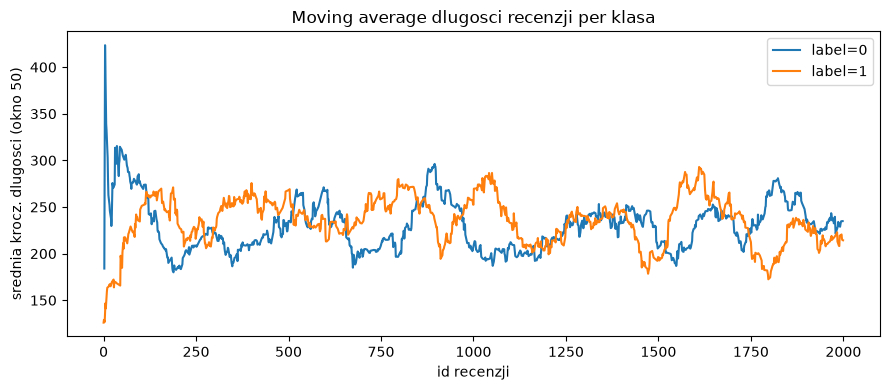

In [11]:
# Zadanie 5.1: window functions na recenzjach
from pyspark.sql.window import Window

# baza: id, label, liczba slow (puste tokeny po splicie usuniete)
base = (df
    .withColumn("tokeny", F.split(F.lower(F.regexp_replace("text", r"<[^>]+>", " ")), r"\W+"))
    .withColumn("word_count", F.size(F.array_remove("tokeny", "")))
    .select("id", "label", "word_count"))

# 1. ranking w obrebie klasy po dlugosci (najdluzsze = rank 1)
w_rank = Window.partitionBy("label").orderBy(F.col("word_count").desc())
ranked = base.withColumn("rank", F.row_number().over(w_rank))

# 2. top 3 najdluzsze recenzje per klasa
print("-- Top 3 najdluzsze recenzje per klasa --")
(ranked
    .filter(F.col("rank") <= 3)
    .select("id", "label", "word_count", "rank")
    .orderBy("label", "rank")
    .show())

# 3. roznica dlugosci od sredniej w klasie
w_class = Window.partitionBy("label")
z_roznica = (base
    .withColumn("avg_wc_klasy", F.round(F.avg("word_count").over(w_class), 1))
    .withColumn("diff_od_sredniej", F.round(F.col("word_count") - F.avg("word_count").over(w_class), 1)))
print("-- Roznica od sredniej klasowej (przyklad) --")
z_roznica.select("id", "label", "word_count", "avg_wc_klasy", "diff_od_sredniej").show(5)

# 4. moving average dlugosci w oknie 50 ostatnich recenzji (po id, w klasie)
w_move = Window.partitionBy("label").orderBy("id").rowsBetween(-49, 0)
moving = base.withColumn("moving_avg_50", F.avg("word_count").over(w_move))

# 5. wykres liniowy: jedna linia na klase
pdf_move = moving.select("label", "id", "moving_avg_50").orderBy("label", "id").toPandas()
fig, ax = plt.subplots(figsize=(9, 4))
for lab, grupa in pdf_move.groupby("label"):
    ax.plot(grupa["id"], grupa["moving_avg_50"], label=f"label={lab}")
ax.set_xlabel("id recenzji")
ax.set_ylabel("srednia krocz. dlugosci (okno 50)")
ax.set_title("Moving average dlugosci recenzji per klasa")
ax.legend()
plt.tight_layout()
plt.show()

### Insight 5.1 — po co tu window functions

Rankingu „top 3 najdłuższe w każdej klasie" i różnicy od średniej klasowej **nie da się** uzyskać zwykłym `groupBy` — agregacja redukuje wiersze, a tu każdy wiersz ma zostać i dostać dodatkową kolumnę liczoną względem swojej grupy. `Window` rozwiązuje to jednym przejściem: `row_number()` numeruje wewnątrz partycji, `avg().over(partitionBy)` rozsyła średnią do każdego wiersza, a `rowsBetween(-49, 0)` daje średnią kroczącą bez self-joinów. Średnia krocząca wygładza szum pojedynczych recenzji i pokazuje, że obie klasy mają zbliżony rozkład długości.

---

# Lab 6 — Data Quality (jakość danych)

## Teoria w trzech zdaniach

**Data Quality** to nie audyt po wszystkim — to **kontrakt** który dane muszą spełnić zanim wejdą do pipeline'u. Sześć wymiarów: kompletność, unikalność, poprawność, zgodność, świeżość, integralność.

Współczesny stack: `pandera`/`great_expectations` dla **deklaratywnych testów**, `pandas-profiling` (teraz `ydata-profiling`) dla **raportów eksploracyjnych**, własne **walidatory** dla reguł biznesowych.

**Reguła:** jeśli nie potrafisz w jednym zdaniu opisać co znaczy "dobre dane" dla Twojego problemu, nie powinieneś jeszcze trenować modelu.

## Przykład rozwiązany: profilowanie imdb — wykrywanie anomalii

In [12]:
import pandas as pd

# Wczytaj wieksza probke
samples_dq = get_imdb_subset("train", 2000)
df_pd = pd.DataFrame(samples_dq, columns=["text", "label"])
df_pd["word_count"] = df_pd["text"].str.split().str.len()
df_pd["char_count"] = df_pd["text"].str.len()

# Profil podstawowy
print("=== KOMPLETNOSC ===")
nulls = df_pd.isnull().sum()
print(f"Nulle: {dict(nulls)}")

print("\n=== UNIKALNOSC ===")
dup_count = df_pd["text"].duplicated().sum()
print(f"Duplikaty tekstu: {dup_count}")

print("\n=== ROZKLAD LABELI ===")
print(df_pd["label"].value_counts(normalize=True).rename("frac"))
balance_ratio = df_pd["label"].value_counts().min() / df_pd["label"].value_counts().max()
print(f"Stosunek mniejszosci do wiekszosci: {balance_ratio:.3f} (1.0 = idealnie zbalansowane)")

print("\n=== ANOMALIE DLUGOSCI ===")
p99 = df_pd["word_count"].quantile(0.99)
p01 = df_pd["word_count"].quantile(0.01)
outliers = df_pd[(df_pd["word_count"] > p99) | (df_pd["word_count"] < p01)]
print(f"P1: {p01:.0f}, P99: {p99:.0f}, outlierow (poza P1-P99): {len(outliers)}")

print("\n=== ANOMALIE TRESCI ===")
has_html = df_pd["text"].str.contains(r"<[^>]+>", regex=True).sum()
very_short = (df_pd["word_count"] < 5).sum()
print(f"Tekst zawiera HTML tagi: {has_html} ({has_html/len(df_pd)*100:.1f}%)")
print(f"Bardzo krotkie recenzje (<5 slow): {very_short}")

print("\nINSIGHT: imdb ma duzo HTML pozostalosci (<br />). Trzeba je czyscic przed treningiem!")

  [timer] get_imdb_subset -> 0.00s
=== KOMPLETNOSC ===
Nulle: {'text': np.int64(0), 'label': np.int64(0), 'word_count': np.int64(0), 'char_count': np.int64(0)}

=== UNIKALNOSC ===
Duplikaty tekstu: 0

=== ROZKLAD LABELI ===
label
1    0.5
0    0.5
Name: frac, dtype: float64
Stosunek mniejszosci do wiekszosci: 1.000 (1.0 = idealnie zbalansowane)

=== ANOMALIE DLUGOSCI ===
P1: 42, P99: 889, outlierow (poza P1-P99): 39

=== ANOMALIE TRESCI ===
Tekst zawiera HTML tagi: 1189 (59.5%)
Bardzo krotkie recenzje (<5 slow): 0

INSIGHT: imdb ma duzo HTML pozostalosci (<br />). Trzeba je czyscic przed treningiem!


## Zadanie 6.1 — Kontrakt danych + raport JSON

**Cel:** zaimplementuj prosty *Data Quality Framework* w czystym Pythonie i wygeneruj raport o jakości datasetu.

**Wymagania:**

1. Klasa `DataContract` z metodą `add_rule(name, callable, severity)` (severity ∈ {`info`, `warning`, `error`}).
2. Klasa `DataValidator` która iteruje po regułach kontraktu i zwraca raport: `{rule_name: {passed: bool, severity, details}}`.
3. Zdefiniuj kontrakt dla imdb z **minimum 6 regułami**:
   - `no_nulls` — brak NULL w `text` i `label`
   - `labels_in_set` — wszystkie labele są w {0, 1}
   - `min_word_count` — każda recenzja ma min. 5 słów
   - `max_word_count` — żadna recenzja > 2000 słów (sanity)
   - `no_duplicates` — brak duplikatów `text`
   - `class_balance` — stosunek klas między 0.5 a 1.5
4. Reguły o severity `error` które zawiodły powinny rzucić wyjątek (fail fast). Reszta jest tylko ostrzeżeniem.
5. Wygeneruj raport w pliku `_workspace/data_quality_report.json` z timestampem.

**Bonus:** zaimplementuj `severity="warning"` regułę `no_html_tags` i pokaż że *raport* o niej mówi, ale walidacja nie zawodzi.

In [13]:
# Zadanie 6.1: DataContract + DataValidator + raport JSON
from datetime import datetime
from dataclasses import dataclass
from typing import Callable

@dataclass
class Rule:
    name: str
    check: Callable
    severity: str = "warning"  # info | warning | error

class DataContract:
    """Zbior nazwanych regul walidacyjnych o przypisanej wadze (severity)."""
    def __init__(self, name: str):
        self.name = name
        self.rules: list[Rule] = []

    def add_rule(self, name: str, check: Callable, severity: str = "warning"):
        self.rules.append(Rule(name=name, check=check, severity=severity))

class DataValidator:
    """Uruchamia reguly kontraktu na DataFrame i zwraca raport; przy bledzie 'error' rzuca wyjatek."""
    def __init__(self, contract: DataContract):
        self.contract = contract

    def validate(self, df) -> dict:
        raport = {}
        bledy_krytyczne = []
        for rule in self.contract.rules:
            try:
                passed = bool(rule.check(df))
                details = "OK" if passed else "regula niespelniona"
            except Exception as exc:
                passed = False
                details = f"wyjatek przy ewaluacji: {exc}"
            raport[rule.name] = {"passed": passed, "severity": rule.severity, "details": details}
            if rule.severity == "error" and not passed:
                bledy_krytyczne.append(rule.name)
        if bledy_krytyczne:
            raise ValueError(f"Reguly krytyczne (error) niespelnione: {bledy_krytyczne}")
        return raport

# kontrakt dla imdb -- 6 regul + bonusowa warning no_html_tags
kontrakt = DataContract("imdb_reviews")
kontrakt.add_rule("no_nulls", lambda d: bool(d[["text", "label"]].notnull().all().all()), "error")
kontrakt.add_rule("labels_in_set", lambda d: set(d["label"].unique()) <= {0, 1}, "error")
kontrakt.add_rule("min_word_count", lambda d: bool((d["word_count"] >= 5).all()), "warning")
kontrakt.add_rule("max_word_count", lambda d: bool((d["word_count"] <= 2000).all()), "warning")
kontrakt.add_rule("no_duplicates", lambda d: not bool(d["text"].duplicated().any()), "warning")
kontrakt.add_rule(
    "class_balance",
    lambda d: 0.5 <= (d["label"].value_counts().min() / d["label"].value_counts().max()) <= 1.5,
    "warning",
)
kontrakt.add_rule("no_html_tags", lambda d: not bool(d["text"].str.contains(r"<[^>]+>", regex=True).any()), "warning")

raport = DataValidator(kontrakt).validate(df_pd)
for nazwa, wynik in raport.items():
    flaga = "PASS" if wynik["passed"] else "FAIL"
    print(f"  [{flaga}] {nazwa:<16} ({wynik['severity']}) -- {wynik['details']}")

# zapis raportu do JSON z timestampem
raport_out = {
    "dataset": "stanfordnlp/imdb",
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "n_rows": int(len(df_pd)),
    "rules": raport,
}
sciezka_raportu = WORKDIR / "data_quality_report.json"
sciezka_raportu.write_text(json.dumps(raport_out, indent=2, ensure_ascii=False))
print(f"\nRaport zapisany: {sciezka_raportu}")

# demonstracja fail-fast: regula 'error' na celowo zepsutych danych rzuca wyjatek
zepsute = pd.DataFrame({"text": ["ok", None], "label": [0, 9]})
kontrakt_demo = DataContract("demo")
kontrakt_demo.add_rule("no_nulls", lambda d: bool(d[["text", "label"]].notnull().all().all()), "error")
try:
    DataValidator(kontrakt_demo).validate(zepsute)
except ValueError as exc:
    print(f"fail-fast zadzialal -> {exc}")

  [PASS] no_nulls         (error) -- OK
  [PASS] labels_in_set    (error) -- OK
  [PASS] min_word_count   (warning) -- OK
  [PASS] max_word_count   (warning) -- OK
  [PASS] no_duplicates    (warning) -- OK
  [PASS] class_balance    (warning) -- OK
  [FAIL] no_html_tags     (warning) -- regula niespelniona

Raport zapisany: _workspace\data_quality_report.json
fail-fast zadzialal -> Reguly krytyczne (error) niespelnione: ['no_nulls']


### Insight 6.1 — audyt vs kontrakt

Reguła `no_html_tags` ma severity `warning`: raport JSON ją odnotowuje (`passed: false`), ale walidacja **nie** zostaje przerwana — bo obecność `<br />` w IMDB to znana właściwość danych, nie błąd blokujący. Reguły `error` (`no_nulls`, `labels_in_set`) działają fail-fast: gdy padną, pipeline zatrzymuje się zanim popsute dane pójdą dalej. To różnica między *audytem* (opis stanu po fakcie) a *kontraktem* (warunek wejścia, który musi być spełniony). W produkcji potrzebne są oba: kontrakt blokuje wjazd złych danych, audyt śledzi trend jakości w czasie.

---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Dekorator:** kiedy `functools.wraps` jest konieczny, a kiedy można sobie odpuścić?
2. **Concurrency:** dlaczego threading nie przyspieszy obliczeń, a multiprocessing przyspieszy?
3. **Testowanie:** kiedy lepiej parametrize, a kiedy osobne testy?
4. **Bazy:** co znaczy *schema-on-read*? Daj praktyczny przykład gdy to plus, a kiedy minus.
5. **Spark:** co to znaczy że transformacja jest "lazy"? Daj przykład **kiedy to boli** w debugowaniu.
6. **Data Quality:** różnica między *audytem* a *kontraktem* danych. W produkcji potrzebujesz obu — dlaczego?

## Co dalej?

- **Pakowanie:** `pyproject.toml`, `poetry`, dystrybucja przez `pip`
- **CI/CD:** GitHub Actions, pre-commit hooks, automated testing
- **Observability:** logging structured (`structlog`), metryki (`prometheus_client`), tracing (`opentelemetry`)
- **Orchestration:** Apache Airflow / Prefect / Dagster do *prawdziwych* pipeline'ów
- **Workshops:** [Real Python](https://realpython.com), [Talk Python To Me](https://talkpython.fm) podcast

In [14]:
# Sprzatanie
try:
    spark.stop()
    print("Spark zatrzymany.")
except NameError:
    pass
print(f"Workspace: {WORKDIR.resolve()}")
print("Wszystkie cache i artefakty zostaja -- usun recznie jesli potrzeba.")

Spark zatrzymany.
Workspace: C:\Workspace\WSEI\LABY-REPO\AAP_Michal_Surzyn\zestaw_zaliczeniowy\_workspace
Wszystkie cache i artefakty zostaja -- usun recznie jesli potrzeba.
